# 실습 3: 자동미분에서 신경망 학습까지

## 이번 실습의 흐름

**자동미분의 원리 → 1차식 → 한 변수의 2차식 → 두 변수의 편미분 → 신경망의 예측과 손실 → 기울기 계산 → 가중치 갱신 → 반복 학습** 순서로 진행한다.

각 셀을 실행하고 출력값을 확인한 뒤 다음 셀로 넘어간다. 간단한 식에서 자동미분을 익히고, 두 변수가 함께 들어 있는 식에서 기울기 벡터를 확인한다. 이어 같은 자동미분으로 신경망을 학습시킨다. 중간의 직접 해보기는 먼저 작성한 뒤 노트북 끝의 해설과 비교한다.

**대응 이론:** [Ch03 손실함수와 경사하강법](https://ralbu85.github.io/lecture_deeplearning/chapters/ch03.html).
Colab 기본 CPU 런타임을 사용한다. 입력값을 바꾸어 다시 확인할 때는 해당 예제의 텐서를 만드는 셀부터 차례로 실행한다.

## 1. 파이토치는 어떻게 미분하는가

### 1.1 계산 과정을 기록하는 자동미분

신경망을 학습시키려면 손실이 각 가중치에 따라 어떻게 변하는지 알아야 한다. 파이토치는 **텐서로 계산한 과정을 기록하고, 그 기록을 이용해 기울기를 구하는 자동미분(autograd)** 기능을 제공한다.

예를 들어 $f(x)=2x+1$을 계산한다고 하자. $x=3$이면 다음 순서로 함수값 7을 얻는다.

```text
x = 3 ── 2를 곱한다 ──→ 6 ── 1을 더한다 ──→ value = 7
```

파이토치는 미분에 필요한 연산과 값의 연결을 **계산 그래프**로 기록한다. 여기에 각 연산의 미분 규칙을 적용하면, 처음 입력한 $x$가 출력 `value`에 미치는 영향을 구할 수 있다.

### 1.2 `backward()`는 무엇을 하는가

**`value.backward()`는 출력 `value`에서 출발해 계산 그래프를 거슬러 가며, 그 출력을 만드는 데 사용한 변수의 기울기를 계산하는 메서드다.** 계산을 진행한 방향의 반대로 돌아가므로 `backward`라고 한다. 이처럼 기울기를 뒤로 전달하는 과정을 **역전파**라고 한다.

위 예제에서는 마지막 덧셈부터 살펴보며, 각 단계의 입력에 대한 변화율을 구한다. 1을 더하는 연산의 변화율은 1이고, 앞의 2를 곱하는 연산의 변화율은 2다. 두 변화율을 연결하면 $x$에 대한 출력의 기울기는 $1\times2=2$다. 이렇게 연산별 변화율을 곱해 연결하는 것이 **연쇄법칙**이다.

```text
value에서 출발 → 덧셈의 변화율 1 → 곱셈의 변화율 2 → x의 기울기 2
```

코드에서는 다음 세 가지를 연결해서 사용한다.

| 코드 | 역할 |
|---|---|
| `requires_grad=True` | 기울기를 구할 텐서를 지정하여 관련 계산을 기록하게 한다. |
| `value.backward()` | 기록한 계산을 거슬러 각 미분 대상에 대한 출력의 기울기를 구한다. |
| `x.grad` | 미분 대상으로 준비한 `x`에 저장된 기울기를 확인한다. |

신경망의 `loss.backward()`도 같은 방식으로 손실에서 출발해 각 가중치의 기울기를 구한다.

**`backward()`는 기울기를 계산한다. 변수의 값을 바꾸지는 않는다.** 뒤에서 사용할 `optimizer.step()`이 그 기울기로 가중치를 갱신한다.

### 1.3 기록한 계산과 기울기를 코드로 확인

먼저 미분할 텐서를 만든다.

In [13]:
import torch

x = torch.tensor(3.0, requires_grad=True) #x=3

In [14]:
x

tensor(3., requires_grad=True)

이 텐서로 함수값을 계산하면 미분에 필요한 과정도 기록된다. `.item()`은 값 하나인 텐서를 파이썬 숫자로 꺼낸다.

In [15]:
value = 2 * x + 1 #함수
print(value.item())

7.0


In [16]:
value #미분 가능하다고 알려줌

tensor(7., grad_fn=<AddBackward0>)

출력은 **7**이다. 이제 이 출력에 `backward()`를 호출하고, 입력 텐서의 `.grad`를 확인한다.

In [17]:
value.backward() # value를 x에 대해서 미분해라.
print(x.grad.item()) # x=3인 시점에서 value의 미분값은 2.0이다.

2.0


기울기는 **2**다. `value`는 함수값 7, `x.grad`는 $x$에 대한 기울기 2를 담고 있다. 같은 절차를 2차식과 두 변수의 함수에도 적용해 보자.

## 2. 2차식에서는 위치에 따라 기울기가 달라진다

### 2.1 함수값 계산

이번에는 다음 함수를 사용한다.

$$f(x)=x^2$$

새 텐서로 $x=3$을 준비하고, `** 2`로 제곱을 계산한다.

In [18]:
x = torch.tensor(3.0, requires_grad=True)
value = x ** 2
print(value.item())

9.0


함수값은 **9**다. 이번에도 같은 `backward()`로 기울기를 구할 수 있다.

### 2.2 기울기 계산

In [19]:
value.backward()
print(x.grad.item()) #값만 나오게 함 item을 붙이면

6.0


출력은 **6**이다. 도함수 $f'(x)=2x$에 3을 넣은 결과와 같다. 파이토치는 도함수를 직접 적지 않아도 텐서로 계산한 과정에서 기울기를 구해 준다.

### 2.3 직접 해보기 ① — 다른 위치에서 확인

아래 셀을 완성하고 `start`를 **-3.0, 0.0, 3.0**으로 바꾸어 실행한다. 각 위치의 함수값과 기울기를 먼저 예상한다.

In [22]:
# ✏️ 직접 채워 보세요
start = 3.
x = torch.tensor(start, requires_grad=True)

# ① value에 x의 제곱 계산
value = x ** 2
# ② 기울기 계산
value.backward()
# ③ 함수값과 기울기 출력
x.grad.item()

6.0

| 입력 | 함수값 | 기울기 |
|---|---|---|
| -3.0 | 9 | -6 |
| 0.0 | 0 | 0 |
| 3.0 | 9 | 6 |

$x=3$에서는 기울기가 양수이므로 $x$를 조금 줄이면 함수값이 작아진다. $x=-3$에서는 기울기가 음수이므로 $x$를 조금 늘려야 한다.

지금까지는 변수 하나의 기울기를 구했다. 신경망에는 가중치가 여러 개 있으므로, 이번에는 변수가 두 개일 때 각 변수의 기울기를 구해 보자.

## 3. 두 변수의 편미분을 기울기 벡터로 확인하기

### 3.1 두 변수가 함께 들어 있는 함수

다음과 같이 두 변수로 함수값 하나를 계산한다고 하자.

$$f(x_1,x_2)=x_1^2+x_1x_2+2x_2^2$$

가운데 항 $x_1x_2$에는 두 변수가 함께 들어 있다. 현재 위치를 $(2,-1)$로 정하고 두 값을 하나의 텐서에 담는다. **`x[0]`은 $x_1$, `x[1]`은 $x_2$**다.

In [23]:
x = torch.tensor([2.0, -1.0], requires_grad=True) # x1 = 2.0 , x2 = -1.0
print(x)

tensor([ 2., -1.], requires_grad=True)


### 3.2 함수값 계산

식을 그대로 코드로 옮긴다.

In [24]:
value = x[0] ** 2 + x[0] * x[1] + 2 * x[1] ** 2 #x[0]= x1, x[1] =x2
print(value.item())

4.0


함수값은 **4**다. $2^2+2\times(-1)+2\times(-1)^2=4$와 비교한다.

### 3.3 두 편미분값을 한 번에 계산

각 변수를 어느 방향으로 바꿀지 판단하려면, **다른 변수를 고정한 채 해당 변수에 대한 변화율**을 구해야 한다. 따라서 $x_1$으로 미분할 때는 $x_2$를 상수로, $x_2$로 미분할 때는 $x_1$을 상수로 취급한다.

$$\frac{\partial f}{\partial x_1}=2x_1+x_2,\qquad
\frac{\partial f}{\partial x_2}=x_1+4x_2$$

$(2,-1)$에서의 편미분값은 각각 **3, -2**다. 이제 코드로 확인한다.

In [25]:
value.backward()
print(x.grad)

tensor([ 3., -2.])


`tensor([3., -2.])`가 나온다. **한 번의 `backward()`로 두 변수의 편미분값을 모두 계산했다.** `x.grad`에는 `x`의 변수 순서대로 값이 들어 있다.

| 변수 | 편미분값 | 함수값을 줄이기 위한 이동 방향 |
|---|---|---|
| $x_1$ | 3 | 조금 줄인다. |
| $x_2$ | -2 | 조금 늘린다. |

두 편미분값을 모은 **기울기 벡터**는 $(3,-2)$다. 함수값을 줄이려면 그 반대인 $(-3,2)$ 방향으로 조금 이동한다. 가운데 곱 항 때문에 각 편미분값에는 다른 변수의 값도 들어 있다.

### 3.4 직접 해보기 ② — 두 변수의 값 바꾸기

아래 셀을 완성해 $(1,2)$에서 함수값과 기울기 벡터를 구한다. 먼저 위 식으로 예상값을 계산한 뒤 실행 결과와 비교한다.

In [28]:
# ✏️ 직접 채워 보세요
x = torch.tensor([-2, 1.0], requires_grad=True)

# ① value에 x[0] ** 2 + x[0] * x[1] + 2 * x[1] ** 2 계산
value = x[0] ** 2 + x[0]*x[1] + 2 * x[1] ** 2
# ② value.backward()로 두 변수의 기울기 계산
value.backward()
# ③ value.item()과 x.grad 출력
x.grad

tensor([-3.,  2.])

다음으로 위치를 $(-2,1)$로 바꾸어 확인한다. 각 위치에서 두 변수를 늘릴지 줄일지도 기록한다.

| 현재 위치 | 함수값 | 기울기 벡터 | 두 변수의 이동 방향 |
|---|---|---|---|
| $(1,2)$ | 직접 기록 | 직접 기록 | 직접 기록 |
| $(-2,1)$ | 직접 기록 | 직접 기록 | 직접 기록 |

이제 이 계산을 신경망에 적용한다. **신경망에서는 여러 가중치와 편향으로 손실 하나를 계산하고, `backward()`로 각 값에 대한 기울기를 함께 구한다.** 먼저 모델의 예측과 정답으로 손실을 만들어 보자.

## 4. 신경망의 예측과 정답 준비하기

### 4.1 학습할 데이터

두 입력 변수로 숫자 하나를 예측하는 작은 회귀 문제를 가정하자. 입력과 정답은 아래에 준비되어 있다. 각 입력 행과 같은 순서의 정답 행이 한 쌍이다.

In [29]:
X = torch.tensor([[0., 0.],
                  [0., 1.],
                  [1., 0.],
                  [1., 1.],
                  [2., 0.],
                  [0., 2.]])

y = torch.tensor([[1.0],
                  [2.0],
                  [1.5],
                  [2.5],
                  [2.0],
                  [3.0]])

print("입력:", X.shape)
print("정답:", y.shape)

입력: torch.Size([6, 2])
정답: torch.Size([6, 1])


`X`는 **행이 데이터, 열이 입력 변수**다. 데이터 6건에 입력 변수가 2개이므로 `(6, 2)`다. 정답은 각 데이터에 숫자 하나씩 있으므로 `(6, 1)`이다.

### 4.2 입력과 출력에 맞는 모델 만들기

실습 2처럼 `torch.nn`의 층을 `nn.Sequential`로 연결한다. `nn.Linear(입력 개수, 출력 개수)`의 두 숫자를 다음 구조에 맞춘다.

```text
입력 2개 → Linear(2, 4) → ReLU → Linear(4, 1) → 예측값 1개
``` 2 -> 4 -> 1
(2+1)*4 + (4+1) * 1 = 17개의 가중치

입력 변수는 2개이고 예측할 값은 하나다. 은닉층의 뉴런 수는 4개로 정한다. 마지막 층의 가중치를 나중에 확인할 수 있도록 `output_layer`라는 이름을 붙인다.

In [30]:
import torch.nn as nn

torch.manual_seed(42)  # 같은 초기 가중치로 결과 비교
hidden_layer = nn.Linear(2, 4) # 2-> 4
output_layer = nn.Linear(4, 1) # 4-> 1

model = nn.Sequential(
    hidden_layer,
    nn.ReLU(),
    output_layer,
)
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)


첫 층의 출력 4개가 마지막 층의 입력 4개로 연결되는지 확인한다.

### 4.3 현재 모델로 예측

`model(X)`는 현재 가중치로 여섯 입력의 예측값을 계산한다.

In [38]:
pred = model(X) #가중치 무작위로 생성
print("예측값:")
print(pred) # 추측값
print("정답:")
print(y) # 데이터

예측값:
tensor([[0.7545],
        [0.9853],
        [0.9262],
        [1.1631],
        [1.0886],
        [1.2512]], grad_fn=<AddmmBackward0>)
정답:
tensor([[1.0000],
        [2.0000],
        [1.5000],
        [2.5000],
        [2.0000],
        [3.0000]])


처음 두 예측값은 약 **0.7545, 0.9853**이고 정답은 **1.0, 2.0**이다. 아직 학습하지 않았으므로 차이가 있다. 이 차이를 숫자로 나타내는 손실을 계산한다.

## 5. 예측 오차를 손실로 바꾸기

### 5.1 예측과 정답의 차이

먼저 각 데이터에서 예측값과 정답의 차이를 구한다.

In [37]:
error = pred - y
print(error)

tensor([[-0.2455],
        [-1.0147],
        [-0.5738],
        [-1.3369],
        [-0.9114],
        [-1.7488]], grad_fn=<SubBackward0>)


첫 데이터의 오차는 약 **-0.2455**다. 예측값이 정답보다 그만큼 작다.

### 5.2 오차를 제곱하고 평균

양수와 음수 오차가 서로 상쇄되지 않도록 제곱한다.

In [33]:
squared_error = error ** 2
print(squared_error)

tensor([[0.0602],
        [1.0296],
        [0.3292],
        [1.7873],
        [0.8307],
        [3.0584]], grad_fn=<PowBackward0>)


첫 데이터의 제곱오차는 약 **0.0602**다. 여섯 제곱오차의 평균을 내면 모델의 전체 손실이 된다.

In [34]:
manual_loss = squared_error.mean()
print(manual_loss.item())

1.1825798749923706


결과는 약 **1.1826**이다. 이것이 이론에서 배운 **평균제곱오차(MSE)**다.

$$J=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2$$

여기서 $N$은 데이터 수, $\hat{y}_i$는 모델의 예측값, $y_i$는 정답이다.

### 5.3 같은 손실을 `nn.MSELoss`로 계산

`nn.MSELoss()`로 손실을 계산할 객체를 만들고 `criterion`이라는 이름을 붙인다. 이후 **`criterion(예측값, 정답)`**으로 호출한다.

In [35]:
criterion = nn.MSELoss() # MSE를 한번에 해줌, 회귀문제에서 손실함수
loss = criterion(pred, y)
print(loss.item())

1.1825798749923706


직접 계산한 값과 같은 **약 1.1826**이 나온다. 이후 학습에서는 이 부품을 사용한다. 예측값과 정답은 모두 `(6, 1)`로, 각 행끼리 비교된다.

### 5.4 직접 해보기 ③ — 손실값 예상

다음 두 경우의 손실을 예상한 뒤 `criterion`으로 확인한다.

1. 예측값이 정답과 완전히 같은 경우: 예측값으로 `y`를 전달한다.
2. 모든 예측값이 정답보다 1씩 큰 경우: 예측값으로 `y + 1`을 전달한다.

In [42]:
# ✏️ 직접 채워 보세요
print(criterion(y, y).item())
print(criterion(pred, y).item())
# print(criterion(예측값, y).item()) 형태로 두 경우를 확인한다.

0.0
1.0


## 6. 손실의 기울기로 가중치 갱신하기

### 6.1 무엇에 대해 미분하는가

앞에서는 $x$가 바뀔 때 함수값이 어떻게 변하는지 구했다. 이제는 **모델의 가중치가 바뀔 때 손실이 어떻게 변하는지** 구한다. 입력 `X`와 정답 `y`는 학습 데이터로 두고, 모델의 가중치와 편향을 조절한다.

`nn.Linear`가 만든 가중치와 편향은 기울기를 계산하도록 설정되어 있다. `backward()`는 모델의 예측에서 손실까지 이어진 계산을 따라 이 값들의 기울기를 구한다.

마지막 층의 가중치는 `output_layer.weight`에 있다. 네 은닉 출력을 받아 예측값 하나를 만들므로 가중치도 네 개다.

In [43]:
print("갱신 전 출력층 가중치:")
print(output_layer.weight)

갱신 전 출력층 가중치:
Parameter containing:
tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True)


약 **0.3694, 0.0677, 0.2411, -0.0706**이다. 아래에서 기울기를 계산한 뒤 이 값들이 어떻게 바뀌는지 확인한다.

### 6.2 갱신 도구 준비

`torch.optim`은 가중치 갱신 도구를 모은 모듈이다. 여기서는 `SGD`로 기울기의 반대 방향으로 이동한다.

In [44]:
pred = model(X)
criterion = nn.MSELoss()
loss = criterion(pred, y)
loss.backward() # 가중치에 대한 미분이 실행된다.


In [46]:
output_layer.weight, hidden_layer.weight

(Parameter containing:
 tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True),
 Parameter containing:
 tensor([[ 0.5406,  0.5869],
         [-0.1657,  0.6496],
         [-0.1549,  0.1427],
         [-0.3443,  0.4153]], requires_grad=True))

In [48]:
output_layer.weight.grad, output_layer.weight

(tensor([[-3.0287, -0.4991, -1.2800, -0.8480]]),
 Parameter containing:
 tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True))

In [50]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.05) #SGD = 경사하강법

- `model.parameters()`: 갱신할 모델의 가중치와 편향을 전달한다.
- `lr=0.05`: 한 번의 이동 크기를 조절하는 **학습률**이다.

`optimizer`에는 기울기를 지우는 `zero_grad()`와 가중치를 갱신하는 `step()`이 있다. 먼저 기울기를 구해 보자.

### 6.3 현재 가중치의 기울기 계산

파이토치는 기울기를 계산할 때 기존 값에 누적한다. `zero_grad()`로 이전 기울기를 지운 뒤, 현재 모델로 예측과 손실을 계산한다.

In [52]:
optimizer.zero_grad() #미분값을 초기화
pred = model(X) # 예측값
loss = criterion(pred, y) #손실함수
loss.backward() # 미분(손실함수를 모델의 가중치로 미분)

print("출력층 가중치의 기울기:")
print(output_layer.weight.grad)
print("은닉층 가중치 기울기")
print(hidden_layer.weight.grad)

출력층 가중치의 기울기:
tensor([[-3.0287, -0.4991, -1.2800, -0.8480]])
은닉층 가중치 기울기
tensor([[-0.4597, -0.7202],
        [ 0.0000, -0.1019],
        [-0.3000, -0.4701],
        [ 0.0315,  0.1376]])


기울기는 약 **-3.0287, -0.4991, -1.2800, -0.8480**이다. 각 값은 같은 순서의 가중치에 대한 편미분값이다.

이 예제에서는 네 기울기가 모두 음수이므로, 손실을 줄이려면 해당 가중치를 조금 늘리는 방향으로 이동한다. **아직 가중치는 갱신하지 않았다.** 다음 셀에서 6.1절의 값이 그대로인지 확인한다.

In [53]:
print(output_layer.weight)

Parameter containing:
tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True)


### 6.4 가중치 갱신

`optimizer.step()`은 저장된 기울기와 학습률로 가중치와 편향을 갱신한다.

$$w_{\text{새}}=w-\eta\frac{\partial J}{\partial w}$$

첫 번째 출력층 가중치는 다음과 같이 바뀐다.

$$0.3694-0.05\times(-3.0287)\approx0.5208$$

In [54]:
optimizer.step() # 현재 가중치에서 주어진 학습률만큼 기울기 벡터의 반대방향으로 이동시킨다.

print("갱신 후 출력층 가중치:")
print(output_layer.weight)

갱신 후 출력층 가중치:
Parameter containing:
tensor([[ 0.5208,  0.0927,  0.3051, -0.0282]], requires_grad=True)


In [55]:
hidden_layer.weight

Parameter containing:
tensor([[ 0.5636,  0.6229],
        [-0.1657,  0.6546],
        [-0.1399,  0.1662],
        [-0.3458,  0.4084]], requires_grad=True)

약 **0.5208, 0.0927, 0.3051, -0.0282**로 바뀐다. 여기서는 출력층을 확인했지만, `model.parameters()`로 전달한 은닉층과 출력층의 가중치·편향이 모두 갱신된다.

### 6.5 새 가중치로 예측과 손실 확인

가중치를 바꾼 효과를 보려면 새 가중치로 다시 예측해야 한다.

In [57]:
pred_after = model(X) # 한번 미분으로 가중치가 업데이트 된 상태
loss_after = criterion(pred_after, y) # 갱신된 가중치로 다시 계산한 결과

print("갱신 후 예측값:")
print(pred_after)
print("갱신 전 손실:", loss.item())
print("갱신 후 손실:", loss_after.item())

갱신 후 예측값:
tensor([[1.0171],
        [1.3936],
        [1.2715],
        [1.6413],
        [1.5224],
        [1.8179]], grad_fn=<AddmmBackward0>)
갱신 전 손실: 1.1825798749923706
갱신 후 손실: 0.46386489272117615


손실이 약 **1.1826 → 0.4639**로 줄었다. 첫 두 예측값도 약 **1.0171, 1.3936**으로 바뀌었다. 각 정답과 비교한다.

방금 실행한 과정을 다음 순서로 짚어 본다.

| 단계 | 코드 | 확인한 것 |
|---|---|---|
| 이전 기울기 초기화 | `optimizer.zero_grad()` | 새 계산을 준비 |
| 예측 | `pred = model(X)` | 현재 가중치의 출력 |
| 손실 계산 | `loss = criterion(pred, y)` | 정답과의 차이 |
| 기울기 계산 | `loss.backward()` | 각 가중치를 바꿀 방향 |
| 갱신 | `optimizer.step()` | 실제 가중치 변화 |

## 7. 한 번의 학습을 반복문으로 연결하기

### 7.1 같은 다섯 줄을 반복

한 번 갱신한 모델을 이어서 학습시킨다. 매번 **새 가중치로 예측과 손실을 다시 계산**하고, 그 위치의 기울기를 구한다.

전체 학습 데이터를 한 번 사용하는 단위를 **에폭(epoch)**이라고 한다. 여기서는 매번 전체 `X`, `y`를 사용하므로 반복 한 번이 한 에폭이다. `loss_history`에는 각 갱신 직전의 손실을 저장하고, `append()`로 값을 추가한다.

In [70]:
loss_history = [] # 손실값을 기록할 리스트
# 모델 가중치 초기화 및 만들기
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
)
# 가중치 갱신 도우미(옵티마이저) 초기화
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
# 학습루프를 설계
for epoch in range(200): # 아래 과정을 200번 반복하라
    optimizer.zero_grad() # 미분 초기화
    pred = model(X) # 데이터를 넣어서 예측
    loss = criterion(pred, y) # 손실함수 계산
    loss.backward() # 미분값 계산
    optimizer.step()  # 현재 미분값을 바탕으로 가중치 갱신

    loss_history.append(loss.item()) # 매번 반복하면서 갱신된 손실값을 넣어라

print("반복 시작 손실:", loss_history[0])
print("반복 종료 후 손실:", criterion(model(X), y).item())

반복 시작 손실: 3.2545812129974365
반복 종료 후 손실: 0.00026258299476467073


손실이 약 **0.4639 → 0.00069**로 줄어든다. 아래에서는 그 과정을 그림으로 확인한다.

### 7.2 손실 그래프 확인 — 제공 코드

`matplotlib.pyplot`은 그래프를 그리는 모듈이다. 다음 코드는 그대로 실행한다. 가로축은 학습 횟수, 세로축은 손실이다.

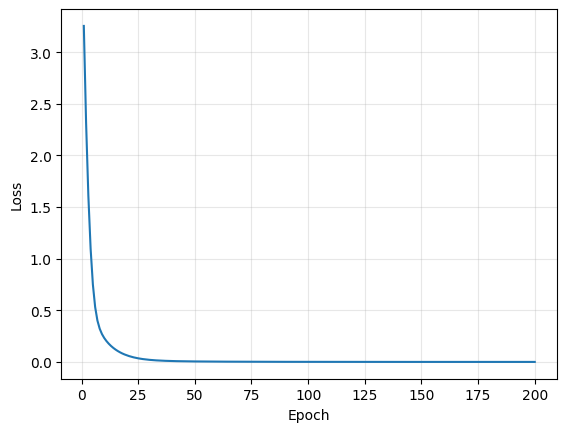

In [71]:
import matplotlib.pyplot as plt

plt.plot(range(1, 201), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

### 7.3 학습한 모델로 예측

학습이 끝난 뒤 결과를 확인할 때는 추가 기울기 계산이 필요하지 않다. `with torch.no_grad():` 안에서는 미분을 위한 계산 기록 없이 예측한다.

In [72]:
with torch.no_grad(): # 이번 연산에서는 미분을 사용하지 않은 상태로
    final_pred = model(X)

print("학습 후 예측값:")
print(final_pred)
print("정답:")
print(y)

학습 후 예측값:
tensor([[1.0002],
        [2.0049],
        [1.5064],
        [2.4658],
        [2.0127],
        [3.0134]])
정답:
tensor([[1.0000],
        [2.0000],
        [1.5000],
        [2.5000],
        [2.0000],
        [3.0000]])


첫 두 예측값은 약 **1.0125, 1.9828**로 정답 **1.0, 2.0**에 가까워졌다. 나머지 행도 비교한다.

이번에는 학습에 사용한 데이터로 결과를 확인했다. 다음 실습에서는 데이터를 나누어 새로운 데이터에 대한 성능을 평가한다.

## 8. 직접 해보기 ④ — 학습 코드 완성하기

이번에는 같은 구조의 모델을 새로 만들고 직접 학습시킨다. 아래 준비 셀은 그대로 실행한다.

In [73]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

print("새 모델의 손실:", criterion(model(X), y).item())

새 모델의 손실: 1.1825798749923706


초기 손실은 다시 약 **1.1826**이다. 다음 반복문에서 주석을 학습 코드 다섯 줄로 바꾼다. 먼저 작성한 뒤 7.1절과 비교한다.

In [74]:
# ✏️ 직접 채워 보세요
for epoch in range(200):
    # ① 이전 기울기 지우기
    optimizer.zero_grad()
    # ② model에 X를 넣어 pred 계산
    pred = model(X)
    # ③ pred와 y로 loss 계산
    loss = criterion(pred, y)
    # ④ 기울기 계산
    loss.backward()
    # ⑤ 가중치 갱신
    optimizer.step()
    pass  # 다섯 줄을 작성한 뒤 삭제

print("학습 후 손실:", criterion(model(X), y).item())

학습 후 손실: 0.000691569410264492


작성 후 다음을 확인한다.

1. 손실이 약 0.00069까지 줄었는가?
2. 기울기를 계산하는 줄과 가중치를 바꾸는 줄은 각각 무엇인가?
3. 은닉층을 6개로 바꾸려면 두 `Linear`의 숫자를 어떻게 바꿔야 하는가?

마지막으로 준비 셀의 은닉층을 6개로 바꾸고, 준비 셀과 작성한 반복문을 차례로 실행한다. 층의 크기를 바꾸어도 같은 학습 코드를 사용할 수 있는지 확인한다.

## 마무리

한 변수에서는 기울기 하나를, 두 변수에서는 편미분값을 모은 기울기 벡터를 구했다. 신경망에서도 같은 `backward()`로 **각 가중치와 편향에 대한 손실의 기울기**를 구하고, `optimizer.step()`으로 모델을 갱신했다.

다음 [실습 4](https://ralbu85.github.io/lecture_deeplearning/labs/lab04.html)에서는 이 학습 코드에 데이터 전처리·분할·미니배치·평가를 연결한다.

## 직접 해보기 해설 — 먼저 작성한 뒤 확인

> **① 한 변수의 2차식**
>
>
> ```python
> start = -3.0
> x = torch.tensor(start, requires_grad=True)
> value = x ** 2
> value.backward()
> print(value.item())
> print(x.grad.item())
> ```
>
> | 입력 | 함수값 | 기울기 |
> |---|---|---|
> | -3.0 | 9 | -6 |
> | 0.0 | 0 | 0 |
> | 3.0 | 9 | 6 |
>
> -3과 3에서는 함수값이 같지만 기울기의 부호가 다르다. 함수값을 줄이려면 서로 반대 방향으로 이동해야 한다.


> **② 두 변수의 편미분**
>
>
> ```python
> x = torch.tensor([1.0, 2.0], requires_grad=True)
> value = x[0] ** 2 + x[0] * x[1] + 2 * x[1] ** 2
> value.backward()
> print(value.item())
> print(x.grad)
> ```
>
> | 현재 위치 | 함수값 | 기울기 벡터 | 함수값을 줄이려면 |
> |---|---|---|---|
> | $(1,2)$ | 11 | $(4,9)$ | 두 변수 모두 조금 줄인다. |
> | $(-2,1)$ | 4 | $(-3,2)$ | 첫 변수는 조금 늘리고, 두 번째는 조금 줄인다. |
>
> $(2,-1)$과 $(-2,1)$에서는 함수값이 4로 같지만 기울기 벡터의 방향은 반대다.


> **③ 손실값 예상**
>
>
> ```python
> print(criterion(y, y).item())
> print(criterion(y + 1, y).item())
> ```
>
> 첫 경우는 모든 오차가 0이므로 손실도 0이다. 두 번째는 모든 제곱오차가 1이므로 평균인 손실도 1이다.


> **④ 학습 코드**
>
>
> ```python
> for epoch in range(200):
>     optimizer.zero_grad()
>     pred = model(X)
>     loss = criterion(pred, y)
>     loss.backward()
>     optimizer.step()
>
> print("학습 후 손실:", criterion(model(X), y).item())
> ```
>
> 기울기는 `loss.backward()`에서 구하고, 가중치는 `optimizer.step()`에서 바꾼다.
>
> 은닉층이 6개라면 `nn.Linear(2, 6)`과 `nn.Linear(6, 1)`을 연결한다. 모델과 `optimizer`를 만드는 준비 셀을 다시 실행하고, 같은 반복문으로 학습시킨다.